In [1]:
import pyodbc
import pandas as pd

conn = pyodbc.connect(
    "DRIVER={ODBC Driver 17 for SQL Server};"
    "SERVER=DESKTOP-FI06HJG;"
    "DATABASE=AdventureWorksDW2014;"
    "Trusted_Connection=yes;"
)

print("Conectado no AdventureWorksDW2014!")

Conectado no AdventureWorksDW2014!


In [2]:
query = """
SELECT TABLE_SCHEMA, TABLE_NAME
FROM INFORMATION_SCHEMA.TABLES
WHERE TABLE_TYPE = 'BASE TABLE'
ORDER BY TABLE_NAME
"""

tabelas = pd.read_sql(query, conn)
display(tabelas)

C:\Users\scien\AppData\Local\Temp\ipykernel_9972\3753498001.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  tabelas = pd.read_sql(query, conn)


,TABLE_SCHEMA,TABLE_NAME
0,dbo,AdventureWorksDWBuildVersion
1,dbo,DatabaseLog
2,dbo,DimAccount
3,dbo,DimCurrency
4,dbo,DimCustomer
5,dbo,DimDate
6,dbo,DimDepartmentGroup
7,dbo,DimEmployee
8,dbo,DimGeography
9,dbo,DimOrganization


In [3]:
query = """
SELECT
    d.FullDateAlternateKey AS Data,
    p.EnglishProductName AS Produto,
    pc.EnglishProductCategoryName AS Categoria,
    st.SalesTerritoryCountry AS Pais,
    fis.SalesAmount AS Vendas,
    fis.OrderQuantity AS Quantidade
FROM FactInternetSales fis
JOIN DimDate d ON fis.OrderDateKey = d.DateKey
JOIN DimProduct p ON fis.ProductKey = p.ProductKey
JOIN DimProductSubcategory ps ON p.ProductSubcategoryKey = ps.ProductSubcategoryKey
JOIN DimProductCategory pc ON ps.ProductCategoryKey = pc.ProductCategoryKey
JOIN DimSalesTerritory st ON fis.SalesTerritoryKey = st.SalesTerritoryKey
"""

df = pd.read_sql(query, conn)

display(df.head())

C:\Users\scien\AppData\Local\Temp\ipykernel_9972\221308170.py:17: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,Data,Produto,Categoria,Pais,Vendas,Quantidade
0,2010-12-29,"Road-150 Red, 62",Bikes,Canada,3578.2700,1
1,2010-12-29,"Mountain-100 Silver, 44",Bikes,France,3399.9900,1
2,2010-12-29,"Mountain-100 Silver, 44",Bikes,United States,3399.9900,1
3,2010-12-29,"Road-650 Black, 62",Bikes,United States,699.0982,1
4,2010-12-29,"Mountain-100 Silver, 44",Bikes,Australia,3399.9900,1


In [4]:
total_vendas = df["Vendas"].sum()
total_qtd = df["Quantidade"].sum()
ticket_medio = total_vendas / total_qtd

print("Total de Vendas:", round(total_vendas, 2))
print("Quantidade Vendida:", int(total_qtd))
print("Ticket Médio:", round(ticket_medio, 2))

Total de Vendas: 29358677.22
Quantidade Vendida: 60398
Ticket Médio: 486.09


In [5]:
vendas_pais = df.groupby("Pais")["Vendas"].sum().sort_values(ascending=False)

top_pais = vendas_pais.head(1)

top_pais

Pais
United States    9.389790e+06
Name: Vendas, dtype: float64

In [6]:
top_pais_nome = top_pais.index[0]
top_pais_valor = top_pais.values[0]

print(f"🌍 Top País: {top_pais_nome}")
print(f"💰 Vendas: {round(top_pais_valor, 2)}")

🌍 Top País: United States
💰 Vendas: 9389789.51


c:\Users\scien\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


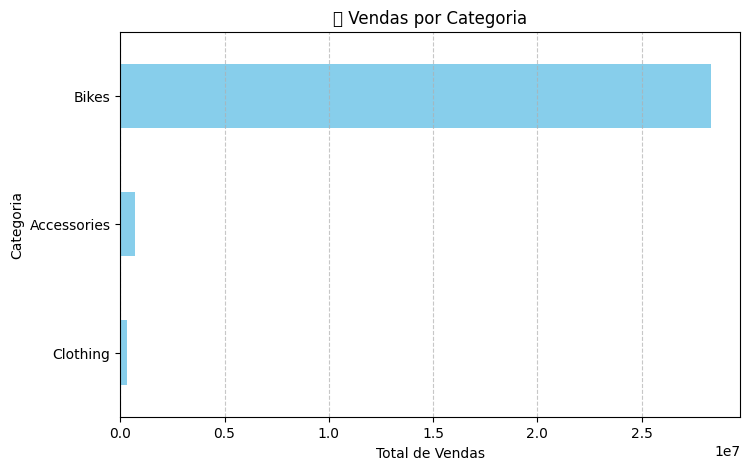

In [7]:
import matplotlib.pyplot as plt

categoria = df.groupby("Categoria")["Vendas"].sum().sort_values()

plt.figure(figsize=(8,5))

categoria.plot(kind="barh", color="skyblue")

plt.title("💰 Vendas por Categoria")
plt.xlabel("Total de Vendas")

plt.grid(axis="x", linestyle="--", alpha=0.7)

plt.show()

c:\Users\scien\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


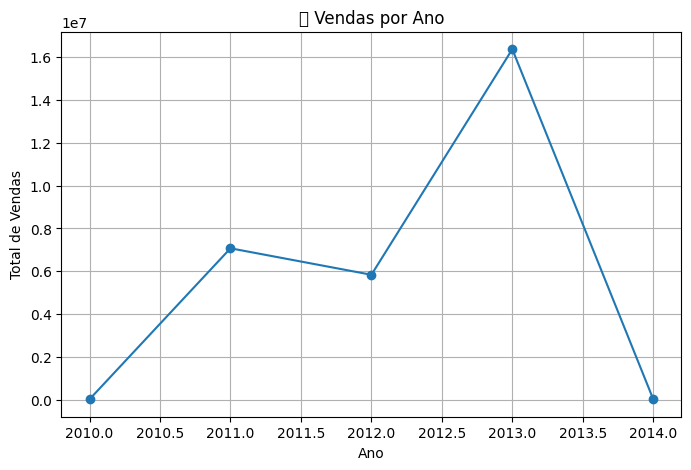

In [8]:
df["Data"] = pd.to_datetime(df["Data"])

vendas_tempo = df.groupby(df["Data"].dt.year)["Vendas"].sum()

plt.figure(figsize=(8,5))

vendas_tempo.plot(marker="o")

plt.title("📈 Vendas por Ano")
plt.xlabel("Ano")
plt.ylabel("Total de Vendas")

plt.grid(True)

plt.show()

C:\Users\scien\AppData\Local\Temp\ipykernel_9972\1129958233.py:35: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\scien\AppData\Local\Temp\ipykernel_9972\1129958233.py:35: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\scien\AppData\Local\Temp\ipykernel_9972\1129958233.py:35: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\scien\AppData\Local\Temp\ipykernel_9972\1129958233.py:35: UserWarning: Glyph 127757 (\N{EARTH GLOBE EUROPE-AFRICA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\scien\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\scien\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: U

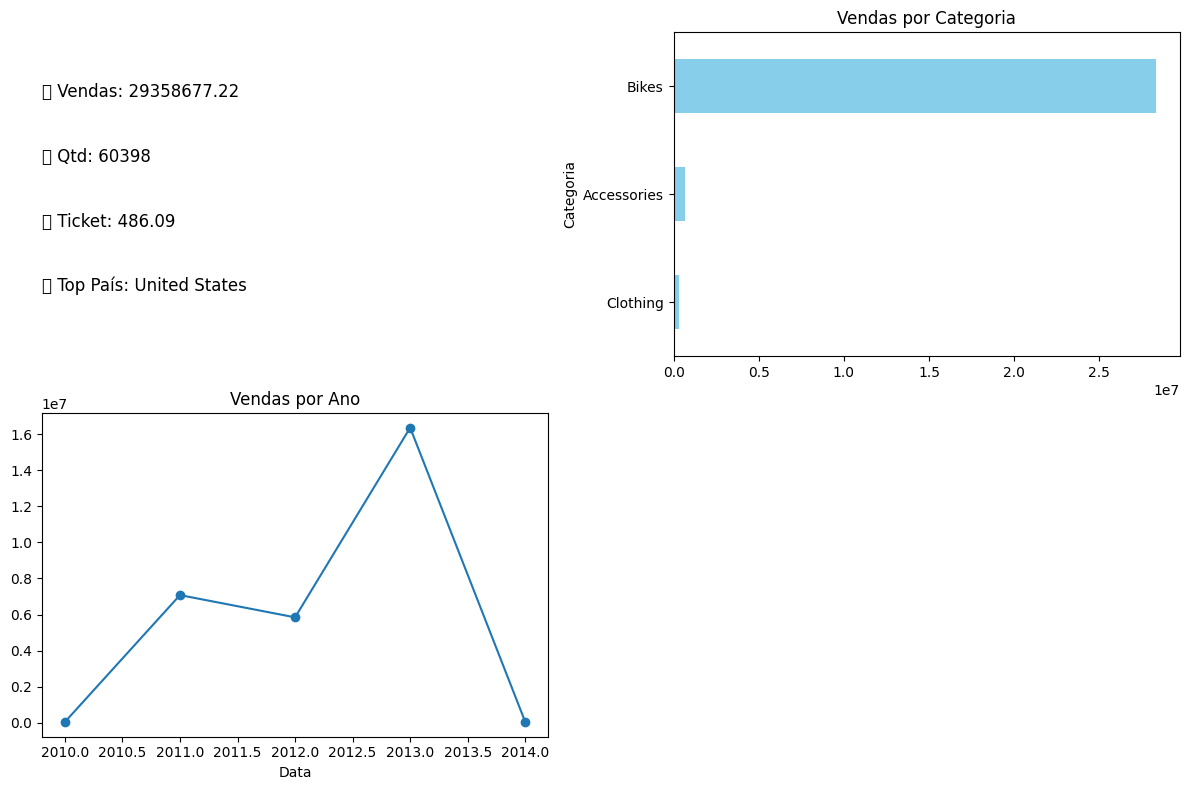

In [9]:
import matplotlib.pyplot as plt

# KPIs
total_vendas = df["Vendas"].sum()
total_qtd = df["Quantidade"].sum()
ticket_medio = total_vendas / total_qtd

top_pais = df.groupby("Pais")["Vendas"].sum().idxmax()

# Dados gráficos
categoria = df.groupby("Categoria")["Vendas"].sum().sort_values()
vendas_tempo = df.groupby(df["Data"].dt.year)["Vendas"].sum()

# Layout
fig, axs = plt.subplots(2, 2, figsize=(12,8))

# KPI (texto)
axs[0,0].axis("off")
axs[0,0].text(0, 0.8, f"💰 Vendas: {round(total_vendas,2)}", fontsize=12)
axs[0,0].text(0, 0.6, f"📦 Qtd: {int(total_qtd)}", fontsize=12)
axs[0,0].text(0, 0.4, f"🎯 Ticket: {round(ticket_medio,2)}", fontsize=12)
axs[0,0].text(0, 0.2, f"🌍 Top País: {top_pais}", fontsize=12)

# Categoria
categoria.plot(kind="barh", ax=axs[0,1], color="skyblue")
axs[0,1].set_title("Vendas por Categoria")

# Temporal
vendas_tempo.plot(ax=axs[1,0], marker="o")
axs[1,0].set_title("Vendas por Ano")

# Espaço vazio (pode usar depois)
axs[1,1].axis("off")

plt.tight_layout()
plt.show()